In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import tqdm
import os
from IPython.display import clear_output
from typing import Optional, Dict, List

import torch.utils.data as data
import torchvision.transforms.v2 as v2
import torch
import torch.nn as nn
from PIL import Image

import wandb
import json
import random

import cv2

sns.set_theme(context="notebook", palette="muted")
RANDOM_STATE = 33

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    return seed

In [4]:
labels = pd.read_parquet('meta_and_target.parquet')
labels['stratify_col'] = labels['source'].astype(str) + '_' + labels['target'].astype(str)

In [ ]:
sex_map = {
    'male' : torch.tensor([1, 0], dtype=torch.float32),
    'female' : torch.tensor([0, 1], dtype=torch.float32),
    None : torch.zeros(2, dtype=torch.float32)
}
anatom_site_map = {'head/neck': torch.tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float32),
                    'upper extremity': torch.tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float32),
                    'lower extremity': torch.tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float32),
                    'torso': torch.tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], dtype=torch.float32),
                    None: torch.tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.], dtype=torch.float32),
                    'palms/soles': torch.tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=torch.float32),
                    'oral/genital': torch.tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], dtype=torch.float32),
                    'anterior torso': torch.tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.], dtype=torch.float32),
                    'posterior torso': torch.tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], dtype=torch.float32),
                    'lateral torso': torch.tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=torch.float32)}

source_map = {'2020' : torch.tensor([1], dtype=torch.float32), '2019' : torch.tensor([0], dtype=torch.float32)}

class ISICDataset(data.Dataset):
    def __init__(self, root, labels, transforms, anatom_site_map, gender_map, source_map):
        super().__init__()
        self.root = root
        self.labels = labels
        self.transforms = transforms
        self.anatom_site_map = anatom_site_map
        self.gender_map = gender_map
        self.source_map = source_map
        self.files = [self.root + f'/{image_id}.jpg' for image_id in self.labels['image'].astype(str).tolist()]
        self.targets = self.labels['target'].astype(float).tolist()
        self.anatom_site = self.labels['anatom_site_general'].tolist()
        self.gender = self.labels['sex'].tolist()
        self.age = self.labels['age_approx'].tolist()
        self.source = self.labels['source'].astype(str).tolist()

    def __len__(self):
        return len(self.files)

    def _get_age_meta(self, age):
        if pd.isna(age):
            return torch.tensor([0.0], dtype=torch.float32)
        return torch.tensor([float(age) / 100.0], dtype=torch.float32)

    def _get_anatom_site_meta(self, site):
        if pd.isna(site):
            site = None
        return self.anatom_site_map.get(site, self.anatom_site_map[None])

    def _get_sex_meta(self, sex):
        if pd.isna(sex):
            sex = None
        return self.gender_map.get(sex, self.gender_map[None])

    def _get_source_meta(self, source):
        return self.source_map[source]

    def __getitem__(self, index):
        image_path = self.files[index]

        with Image.open(image_path) as im:
            im = im.convert('RGB')

        if self.transforms is not None:
            im = self.transforms(im)

        age_meta = self._get_age_meta(self.age[index])
        anatom_site_meta = self._get_anatom_site_meta(self.anatom_site[index])
        sex_meta = self._get_sex_meta(self.gender[index])
        source_meta = self._get_source_meta(self.source[index])
        meta = torch.cat([age_meta, anatom_site_meta, sex_meta, source_meta], dim=0)
        target = torch.tensor(self.targets[index], dtype=torch.float32)

        return im, meta, target

In [6]:
def training_epoch(model : nn.Module, optimizer : torch.optim.Optimizer, criterion : nn.Module, train_loader : data.DataLoader, device : torch.device, scheduler=None, tqdm_desc='Train'):
    model.train()

    loss_sum = 0.0
    n_samples = 0

    all_probs = []
    all_targets = []

    pbar = tqdm.tqdm(train_loader, desc=tqdm_desc)
    for x, meta, y in pbar:
        x = x.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()
        meta = meta.to(device, non_blocking=True).float()

        optimizer.zero_grad()

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            logits = model(x, meta).squeeze(1)
            loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        bs = x.size(0)
        loss_sum += float(loss.item()) * bs
        n_samples += bs

        all_targets.extend(y.cpu().detach().numpy().flatten().tolist())
        all_probs.extend(logits.sigmoid().float().cpu().detach().numpy().flatten().tolist())

        avg_loss = loss_sum / max(1, n_samples)

        pbar.set_postfix({'loss': f'{avg_loss:.4f}', 'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'})

    return {'loss' : loss_sum / max(1, n_samples), 'roc_auc' : roc_auc_score(all_targets, all_probs)}


@torch.no_grad()
def validation_epoch(model : nn.Module, criterion : nn.Module, valid_loader : data.DataLoader, device : torch.device, tqdm_desc='Valid'):
    model.eval()

    loss_sum = 0.0
    n_samples = 0

    all_probs = []
    all_targets = []

    pbar = tqdm.tqdm(valid_loader, desc=tqdm_desc)
    for x, meta, y in pbar:
        x = x.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()
        meta = meta.to(device, non_blocking=True).float()

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            logits = model(x, meta).squeeze(1)
            loss = criterion(logits, y)

        bs = x.size(0)
        loss_sum += float(loss.item()) * bs
        n_samples += bs

        all_targets.extend(y.cpu().detach().numpy().flatten().tolist())
        all_probs.extend(logits.float().sigmoid().cpu().detach().numpy().flatten().tolist())

        avg_loss = loss_sum / max(1, n_samples)

        pbar.set_postfix({'loss': f'{avg_loss:.4f}'})


    return {'loss' : loss_sum / max(1, n_samples), 'roc_auc' : roc_auc_score(all_targets, all_probs)}

def plot_metrics(train_losses, val_losses, train_auc_roc, val_auc_roc):
    clear_output(True)
    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Val Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Dynamics')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_auc_roc, label='Train AUC-ROC', marker='o')
    plt.plot(epochs, val_auc_roc, label='Val AUC-ROC', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('AUC-ROC')
    plt.title('AUC-ROC Dynamics')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim([-0.05, 1.05])
    plt.legend()

    plt.tight_layout()
    plt.show()

def save_checkpoint(path: str, model: nn.Module, optimizer: torch.optim.Optimizer, epoch: int, val_loss : float) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({'epoch': epoch, 'val_loss': val_loss, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict()}, path)

def fit(model : nn.Module, train_loader : data.DataLoader, val_loader : data.DataLoader, optimizer : torch.optim.Optimizer, scheduler, criterion : nn.Module, device : torch.device, num_epochs: int, out_dir: str = None, plot_fn=None, use_wandb: bool = False, wandb_project: str = None, wandb_run_name: Optional[str] = None, wandb_config: Optional[dict] = None, save_every_n_epochs : int = 1) -> Dict[str, List[float]]:
    model.to(device)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_roc_auc' : [],
        'val_roc_auc' : [],
        'lr' : [],
    }

    best_roc_auc = 0

    run = None
    if use_wandb:
        run = wandb.init(project=wandb_project, name=wandb_run_name, config=wandb_config if wandb_config else {}, reinit='create_new')
        run.config.update({'num_params': sum(p.numel() for p in model.parameters()), 'device': str(device)}, allow_val_change=True)

    for epoch in range(1, num_epochs + 1):
        tr = training_epoch(model=model, train_loader=train_loader, optimizer=optimizer, scheduler=scheduler, criterion=criterion, device=device, tqdm_desc=f'Train {epoch}/{num_epochs}')
        va = validation_epoch(model=model, valid_loader=val_loader, criterion=criterion, device=device, tqdm_desc=f'Valid {epoch}/{num_epochs}')

        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr['loss'])
        history['train_roc_auc'].append(tr['roc_auc'])
        history['val_loss'].append(va['loss'])
        history['val_roc_auc'].append(va['roc_auc'])
        history['lr'].append(current_lr)

        if epoch % save_every_n_epochs == 0: save_checkpoint(os.path.join(out_dir, 'checkpoints', f"epoch_{epoch:03d}.pt"), model, optimizer, epoch, va['loss'])
        if va['roc_auc'] >= best_roc_auc:
            save_checkpoint(os.path.join(out_dir, 'checkpoints', 'best.pt'), model, optimizer, epoch, va['loss'])
            best_roc_auc = va['roc_auc']

        print(f'[{epoch:02d}/{num_epochs}] train: loss={tr["loss"]:.4f}, roc_auc={tr["roc_auc"]:.4f} | val: loss={va["loss"]:.4f}, roc_auc={va["roc_auc"]:.4f} | lr={current_lr:.2e}')

        if plot_fn:
            plot_fn(history['train_loss'], history['val_loss'], history['train_roc_auc'], history['val_roc_auc'])

        if use_wandb:
            run.log({'epoch': epoch, 'train/loss': tr['loss'], 'train/roc_auc': tr['roc_auc'], 'val/loss': va['loss'], 'val/roc_auc': va['roc_auc'], 'lr': current_lr}, step=epoch)

        os.makedirs(f'{out_dir}/logs/', exist_ok=True)
        with open(f'{out_dir}/logs/history.json', 'w', encoding='utf-8') as f:
            json.dump(history, f, ensure_ascii=False, indent=4)

    os.makedirs(os.path.dirname(f'{out_dir}/data/'), exist_ok=True)
    artifact = wandb.Artifact('train_data', type='train_data')
    with open(f'{out_dir}/data/train_dataset.pkl', 'wb') as f:
        pickle.dump(train_loader.dataset.files, f)
        artifact.add_file(f'{out_dir}/data/train_dataset.pkl', 'train_dataset.pkl')


    if run: run.log_artifact(artifact)

    artifact = wandb.Artifact('val_data', type='val_data')
    with open(f'{out_dir}/data/val_dataset.pkl', 'wb') as f:
        pickle.dump(val_loader.dataset.files, f)
        artifact.add_file(f'{out_dir}/data/val_dataset.pkl', 'val_dataset.pkl')

    if run: run.log_artifact(artifact)

    artifact = wandb.Artifact('best_model', 'model')
    artifact.add_file(os.path.join(out_dir, 'checkpoints', 'best.pt'), 'best_model.pt')

    if run: run.log_artifact(artifact)

    if use_wandb and run is not None:
        run.finish()

    return history

In [7]:
train_labels, test_labels = train_test_split(labels, test_size=0.3, random_state=RANDOM_STATE, stratify=labels['stratify_col'])
test_labels, val_labels = train_test_split(test_labels, test_size=0.35, random_state=RANDOM_STATE, stratify=test_labels['stratify_col'])

In [9]:
from torchvision.models import resnet152, ResNet152_Weights

class Multimodal(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.conv = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)
        for p in self.conv.parameters():
            p.requires_grad = False

        self.conv.fc = nn.Sequential(nn.Linear(2048, 512), nn.ReLU())
        for p in self.conv.fc.parameters():
            p.requires_grad = True

        self.metaclf = nn.Sequential(
            nn.Linear(14, 64),
            nn.GELU(),
            nn.Linear(64, 64, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU()
        )

        self.clf = nn.Sequential(
            nn.Linear(512 + 64, 64, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, X, meta):
        with torch.no_grad():
            X = self.conv(X)
        meta = self.metaclf(meta)
        return self.clf(torch.cat([X, meta], dim=1))

In [10]:
device = torch.device('cuda')

train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=180, interpolation=v2.InterpolationMode.BILINEAR, fill=0),
    v2.RandomApply([v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03)], p=0.1),
    v2.RandomApply([v2.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))], p=0.1),
    v2.ToImage(),
    v2.ToDtype(torch.float32, True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_dataset = ISICDataset('data/images', train_labels, transforms=train_transforms, anatom_site_map=anatom_site_map, gender_map=sex_map, source_map=source_map)

test_transforms = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, True), v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

test_dataset = ISICDataset('data/images', test_labels, transforms=test_transforms, anatom_site_map=anatom_site_map, gender_map=sex_map, source_map=source_map)
val_dataset = ISICDataset('data/images', val_labels, transforms=test_transforms, anatom_site_map=anatom_site_map, gender_map=sex_map, source_map=source_map)

n_pos = train_labels["target"].sum()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

train_loader = data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=64)
val_loader = data.DataLoader(val_dataset, batch_size=64)

steps_per_epoch = 365
num_epochs = 20
warmup_epochs = 3
warmup_steps = steps_per_epoch * warmup_epochs
total_steps = steps_per_epoch * num_epochs

def lr_lambda(step):
    if step < warmup_steps:
        return float(step + 1) / float(warmup_steps)

    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + np.cos(np.pi * progress))

model = Multimodal()

optimizer = torch.optim.AdamW([{"params": model.conv.fc.parameters(), "lr": 1e-4}, {"params": model.metaclf.parameters(), "lr": 1e-3}, {"params": model.clf.parameters(), "lr": 1e-3}], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 231MB/s]


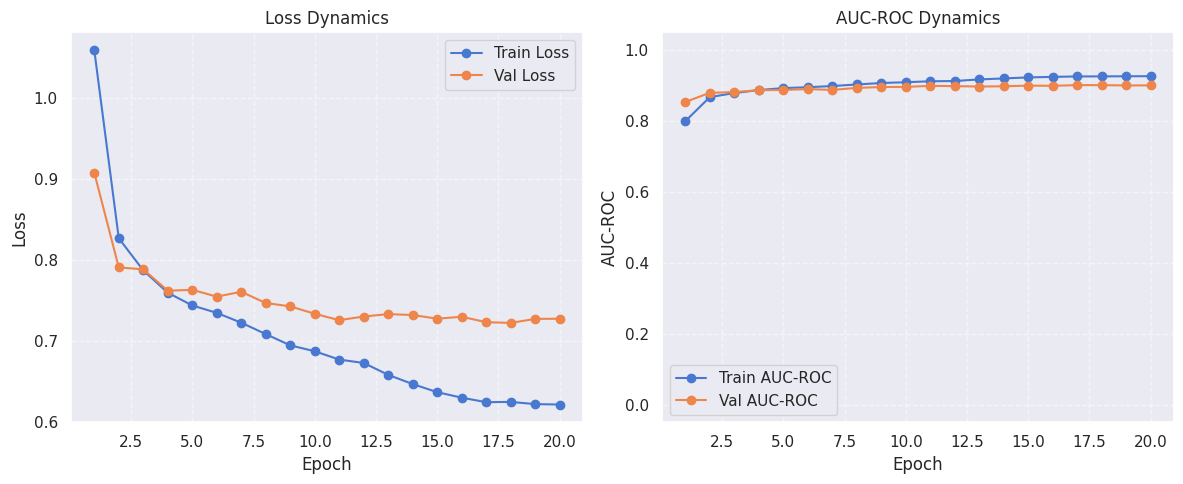

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,▃▆███▇▇▇▆▅▅▄▄▃▂▂▂▁▁▁
train/loss,█▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train/roc_auc,▁▅▅▆▆▆▆▇▇▇▇▇▇███████
val/loss,█▄▃▂▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/roc_auc,▁▅▅▆▆▆▆▇▇▇██▇███████
epoch,20
lr,0
train/loss,0.62133
train/roc_auc,0.92628
val/loss,0.72724


{'train_loss': [1.0589190777738302,
  0.8266033165580391,
  0.7869678591260136,
  0.7593655643771384,
  0.7436326207331437,
  0.7344890549879161,
  0.7223316307893751,
  0.7082946057496952,
  0.6943732164121913,
  0.6870757912177943,
  0.6768153351825955,
  0.6726166247371659,
  0.65793701996254,
  0.6465649762777887,
  0.6365697966266229,
  0.6297717220254265,
  0.6242256094765624,
  0.6245594793673791,
  0.6218443104291653,
  0.6213281354565897],
 'val_loss': [0.9075571496033247,
  0.790560020507233,
  0.7882365009091638,
  0.7618357305319768,
  0.7629102673073076,
  0.7545475206124586,
  0.7605061291763267,
  0.7466537266850539,
  0.7424832576346493,
  0.7333741627510175,
  0.7254580150734419,
  0.7299824344097444,
  0.7329517553221628,
  0.7318108408604943,
  0.7272864661851248,
  0.7297003811117855,
  0.7229484514057262,
  0.7221032186687367,
  0.7270526650767541,
  0.7272393134646522],
 'train_roc_auc': [np.float64(0.7992418206746554),
  np.float64(0.8672163938215145),
  np.float

In [11]:
fit(model, train_loader, val_loader, optimizer, scheduler, criterion, device, num_epochs, out_dir='resnet152multimodal', use_wandb=True, wandb_project='gp5_multimodal_resnset152', wandb_run_name='gp5_multimodal_resnet152_run0', plot_fn=plot_metrics)